In [1]:
DRIVE_ENABLED = True

In [2]:
if DRIVE_ENABLED:
  from google.colab import drive
  drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir /content/data

In [4]:
!cp /content/drive/MyDrive/machine-learning/data/datasets/working.zip /content/data/

In [5]:
!unzip -qq /content/data/working.zip -d /content/data/

In [6]:
!ls -al /content/data/working

test  train


## Initialize

In [7]:
import random
from collections import OrderedDict, defaultdict
from pathlib import Path
import os
from os.path import exists
from shutil import copytree, copy
from sys import stderr
from typing import List, Tuple, Set

import pandas as pd
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [8]:
DATA_PATH = Path("./") / "data"
if DRIVE_ENABLED:
  DATA_PATH = Path("/content/drive/MyDrive/machine-learning/data")
  # DATA_PATH = Path("/content/data")
DATASET_PATH = DATA_PATH / "datasets"
if DRIVE_ENABLED:
  DATASET_PATH = Path("/content/data")
MODEL_DIR_PATH = DATA_PATH / "models"

In [9]:
device = "cpu"
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
device = torch.device(device)

In [10]:
device

device(type='cuda')

## 데이터셋 처리

https://www.kaggle.com/code/tithikhan/face-recognition-with-vgg16

In [11]:
def init_dataset(dataset_path=DATASET_PATH):
    def _init_localfile_exists():
        localfile = dataset_path
        if not exists(localfile):
            print("LFW dataset not found locally, downloading...", file=stderr)
            path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
            copytree(path, localfile, dirs_exist_ok=True)

    def _normalize_name(name):
        return '_'.join(name.replace('_', ' ').split()).strip()

    def _prepare_dataset(df, img_folder, dest_folder):
        for index, row in df.iterrows():
            person_name = _normalize_name(row['name'])
            images_count = int(row['images'])
            person_dir = os.path.join(dest_folder, person_name)  # Folder for the person
            os.makedirs(person_dir, exist_ok=True)

            # Format the image filename
            for i in range(1, images_count + 1):
                filename = f"{person_name}_{i:04d}.jpg"
                source_path = os.path.join(img_folder, person_name, filename)
                dest_path = os.path.join(person_dir, filename)

                # Check if the source file exists and copy
                if os.path.exists(source_path):
                    copy(source_path, dest_path)
                else:
                    print(f"Warning: File not found - {source_path}")


    lfw_path = dataset_path / "lfw-deepfunneled" / "lfw-deepfunneled"
    metadata_path = dataset_path
    lfw_restructured = dataset_path / "working"

    train_path = lfw_restructured / "train"
    test_path = lfw_restructured / "test"

    os.makedirs(lfw_restructured, exist_ok=True)
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    # train_metadata = pd.read_csv(metadata_path / "peopleDevTrain.csv")
    # test_metadata = pd.read_csv(metadata_path / "peopleDevTest.csv")

    _init_localfile_exists()

    # _prepare_dataset(train_metadata, lfw_path, train_path)
    # _prepare_dataset(test_metadata, lfw_path, test_path)

    def _count_files(directory):
        total_files = 0
        for root, dirs, files in os.walk(directory):
            total_files += len(files)
        return total_files

    train_classes = os.listdir(train_path)
    test_classes = os.listdir(test_path)
    all_classes = set(train_classes) | set(test_classes)

    # print(f"Total training images: {_count_files(train_path)}")
    # print(f"Total testing images: {_count_files(test_path)}")
    # print(f"Total classes: {len(all_classes)}")
    return train_path, test_path, all_classes

init_dataset()

(PosixPath('/content/data/working/train'),
 PosixPath('/content/data/working/test'),
 {'4801',
  '4802',
  '4803',
  '4804',
  '4805',
  '4806',
  '4807',
  '4808',
  '4809',
  '4810',
  '4811',
  '4812',
  '4813',
  '4814',
  '4815',
  '4816',
  '4817',
  '4818',
  '4819',
  '4820',
  '4821',
  '4822',
  '4823',
  '4824',
  '4825',
  '4826',
  '4827',
  '4828',
  '4829',
  '4830',
  '4831',
  '4832',
  '4833',
  '4834',
  '4835',
  '4836',
  '4837',
  '4838',
  '4839',
  '4840',
  '4841',
  '4842',
  '4843',
  '4844',
  '4845',
  '4846',
  '4847',
  '4848',
  '4849',
  '4850',
  '4851',
  '4852',
  '4853',
  '4854',
  '4855',
  '4856',
  '4857',
  '4858',
  '4859',
  '4860',
  '4861',
  '4862',
  '4863',
  '4864',
  '4865',
  '4866',
  '4867',
  '4868',
  '4869',
  '4870',
  '4871',
  '4872',
  '4873',
  '4874',
  '4875',
  '4876',
  '4877',
  '4878',
  '4879',
  '4880',
  '4881',
  '4882',
  '4883',
  '4884',
  '4885',
  '4886',
  '4887',
  '4888',
  '4889',
  '4890',
  '4891',
  '48

## 모델 구현

In [12]:
class VGGReimplementation(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # conv1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True),

            # conv2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True),

            # conv3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True),

            # conv4
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True),

            # conv5
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2, return_indices=True)
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

        self.feature_maps = OrderedDict()
        self.pool_locs = OrderedDict()

    def forward(self, x):
        for layer in self.features:
            if isinstance(layer, nn.MaxPool2d):
                x, location = layer(x)
            else:
                x = layer(x)

        x = x.view(x.size()[0], -1)
        x = self.classifier(x)
        return x

In [13]:
class ResNetTransfer(nn.Module):
    def __init__(self, num_classes):
        super(ResNetTransfer, self).__init__()
        self.resnet = models.resnet50(pretrained=True)

        # Feature extraction layers 고정
        for param in self.resnet.parameters():
            param.requires_grad = False

        # 마지막 레이어만 학습
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

In [14]:
class AttentionCNN(nn.Module):
    def __init__(self, num_classes):
        super(AttentionCNN, self).__init__()

        # Feature extraction
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.conv2 = self._make_layer(64, 128, 2)
        self.conv3 = self._make_layer(128, 256, 2)
        self.conv4 = self._make_layer(256, 512, 2)

        # Attention module
        self.attention = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=1),
            nn.Sigmoid()
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def _make_layer(self, in_channels, out_channels, blocks):
        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        for _ in range(1, blocks):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))

        layers.append(nn.MaxPool2d(2, 2))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Apply attention
        att = self.attention(x)
        x = x * att

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

## 학습기

In [15]:
def train_model(model, loader, criterion, optimizer, num_epochs=30):
    losses = []
    accs = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        loss = running_loss / len(loader)
        acc = 100 * correct / total
        losses.append(loss)
        accs.append(acc)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {loss:.4f}, Train Acc: {acc:.2f}% ')

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), 'best_face_model.pth')

    return losses, accs

In [29]:
def evaluate_model(model, test_loader):
    model.eval()
    accuracy = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct_prediction = torch.argmax(outputs, 1) == labels
            accuracy += correct_prediction.float().sum()

        accuracy = accuracy.item() / len(test_loader.dataset)
        print(accuracy)

## 실행

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training vgg model
Epoch [1/100] Train Loss: 5.2046, Train Acc: 0.51% 
Epoch [2/100] Train Loss: 5.1377, Train Acc: 0.37% 
Epoch [3/100] Train Loss: 5.1302, Train Acc: 0.64% 
Epoch [4/100] Train Loss: 5.1279, Train Acc: 0.67% 
Epoch [5/100] Train Loss: 5.1254, Train Acc: 0.53% 
Epoch [6/100] Train Loss: 5.1232, Train Acc: 0.56% 
Epoch [7/100] Train Loss: 5.1234, Train Acc: 0.40% 
Epoch [8/100] Train Loss: 5.1227, Train Acc: 0.35% 
Epoch [9/100] Train Loss: 5.1207, Train Acc: 0.59% 
Epoch [10/100] Train Loss: 5.1188, Train Acc: 0.59% 
Epoch [11/100] Train Loss: 5.1183, Train Acc: 0.53% 
Epoch [12/100] Train Loss: 5.1190, Train Acc: 0.43% 
Epoch [13/100] Train Loss: 5.1149, Train Acc: 0.61% 
Epoch [14/100] Train Loss: 5.1159, Train Acc: 0.43% 
Epoch [15/100] Train Loss: 5.1136, Train Acc: 0.69% 
Epoch [16/100] Train Loss: 5.1170, Train Acc: 0.51% 
Epoch [17/100] Train Loss: 5.1147, Train Acc: 0.51% 
Epoch [18/100] Train Loss: 5.1173, Train Acc: 0.64% 
Epoch [19/100] Train Loss: 5.1137, 

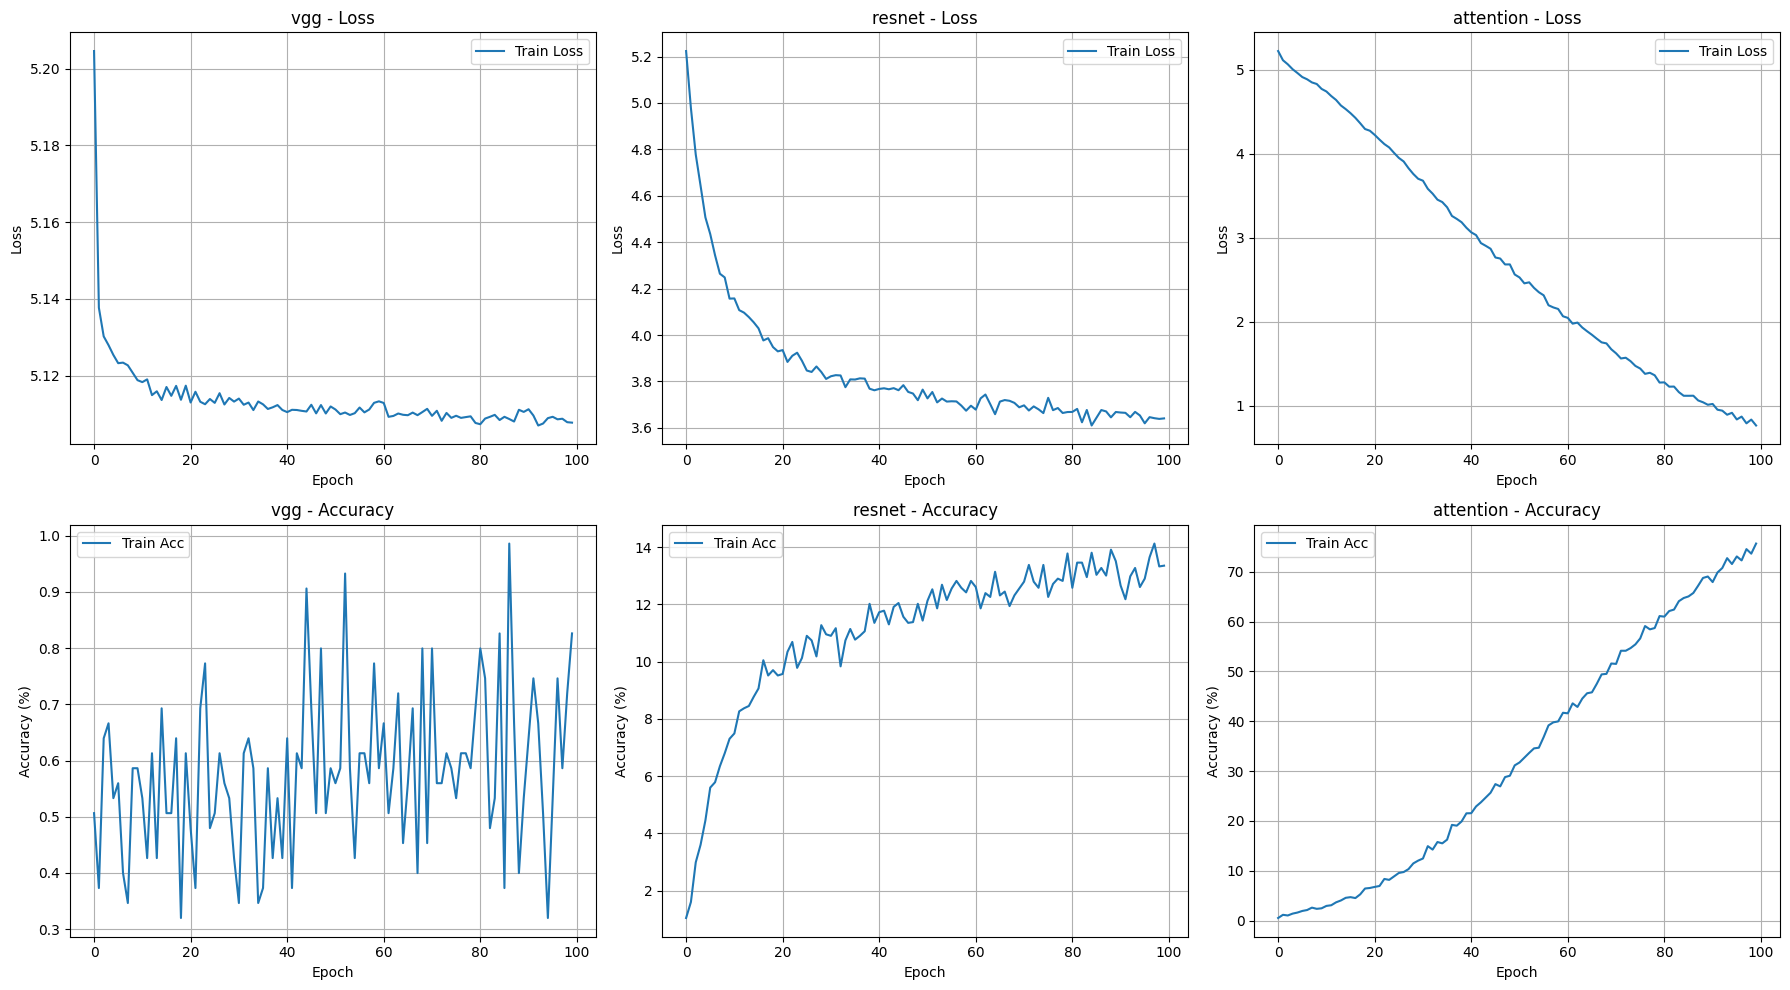

In [21]:
BATCH_SIZE = 32
EPOCHS = 100

train_path, test_path, all_classes = init_dataset(DATASET_PATH)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(
    root=train_path,
    transform=train_transforms,
)

test_dataset = ImageFolder(
    root=test_path,
    transform=test_transforms,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
_models = {
    'vgg': VGGReimplementation(num_classes=len(all_classes)),
    'resnet': ResNetTransfer(num_classes=len(all_classes)),
    'attention': AttentionCNN(num_classes=len(all_classes))
}

results = {}

for model_name, model in _models.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name} model")
    print(f"{'='*50}")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    losses, accs = train_model(
        model, train_loader, criterion, optimizer, EPOCHS
    )

    results[model_name] = {
        'losses': losses,
        'accs': accs,
    }

    # print(f"\nEvaluating {model_name} model on test set:")
    # evaluate_model(model, test_loader, classes)

    torch.save(model.state_dict(), DATA_PATH / f'{model_name}_face_model.pth')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (model_name, result) in enumerate(results.items()):
    # Loss plot
    axes[0, idx].plot(result['losses'], label='Train Loss')
    axes[0, idx].set_title(f'{model_name} - Loss')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True)

    # Accuracy plot
    axes[1, idx].plot(result['accs'], label='Train Acc')
    axes[1, idx].set_title(f'{model_name} - Accuracy')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy (%)')
    axes[1, idx].legend()
    axes[1, idx].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

In [33]:
for model_name, model in _models.items():
    print(model_name)

    model = model.to(device)

    # print(f"\nEvaluating {model_name} model on test set:")
    evaluate_model(model, test_loader)

vgg
0.12295081967213115
resnet
0.004098360655737705
attention
0.01639344262295082


## 추가:
https://arxiv.org/abs/1703.05175

In [18]:
class PrototypicalNetwork(nn.Module):
    def __init__(self, backbone_model: nn.Module):
        super().__init__()
        self.backbone = backbone_model

        if hasattr(self.backbone, 'fc'):
            self.feature_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()

        elif hasattr(self.backbone, 'classifier'):
            first_lin = None
            for layer in self.backbone.classifier:
                if isinstance(layer, nn.Linear):
                    first_lin = layer
                    break
            if first_lin is None:
                raise RuntimeError("Could not find a nn.Linear inside backbone.classifier")
            self.feature_dim = first_lin.in_features   # → should be 25088 for VGG
            self.backbone.classifier = nn.Identity()

        else:
            raise RuntimeError("Backbone has no .fc or .classifier to strip.")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # After removing the final head, backbone(x) returns exactly the flattened features:
        #  - VGG:  convs → flatten(…, 25088) → Identity → output [B, 25088]
        #  - ResNet: convs→avgpool→flatten(…,512) → Identity → output [B, 512]
        return self.backbone(x)

    def compute_prototypes(self,
                           support_features: torch.Tensor,
                           support_labels:   torch.Tensor):
        unique_labels = torch.unique(support_labels)
        num_classes   = unique_labels.size(0)
        device        = support_features.device

        prototypes = torch.zeros(num_classes, self.feature_dim, device=device)
        for i, lbl in enumerate(unique_labels):
            mask = support_labels == lbl
            # support_features[mask].mean(dim=0)  =>   [feature_dim]
            prototypes[i] = support_features[mask].mean(dim=0)
        return prototypes, unique_labels

    def classify(self,
                 query_features: torch.Tensor,
                 prototypes:     torch.Tensor):
        """
        query_features: [B, feature_dim]
        prototypes:     [P, feature_dim]

        Returns:
          distances: [B, P] = Euclidean distances
          sims:      [B, P] = 1/(1 + distance)
        """
        distances = torch.cdist(query_features, prototypes)  # [B, P]
        sims      = 1.0 / (1.0 + distances)
        return distances, sims


In [19]:
class FaceRegistration:
    def __init__(self,
                 pretrained_model_path: str,
                 model: nn.Module,
                 original_num_classes: int):

        self.model = model(num_classes=original_num_classes)
        self.model.load_state_dict(torch.load(pretrained_model_path, map_location=device))
        self.model.to(device)
        self.model.eval()

        self.proto_net = PrototypicalNetwork(self.model)
        self.proto_net.to(device)
        self.proto_net.eval()

        self.prototypes = None             # Tensor [P, feature_dim]
        self.prototype_labels: List[int] = []
        self.label_to_name:  Dict[int,str] = {}
        self.name_to_label:  Dict[str,int] = {}
        self.next_label = 0

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def register_new_person(self, person_name: str, image_paths: List[str]) -> bool:
        if person_name in self.name_to_label:
            person_label = self.name_to_label[person_name]
        else:
            person_label = self.next_label
            self.name_to_label[person_name] = person_label
            self.label_to_name[person_label] = person_name
            self.next_label += 1

        features_list = []
        with torch.no_grad():
            for i, img_path in enumerate(image_paths):
                try:
                    img = Image.open(img_path).convert('RGB')
                    x = self.transform(img).unsqueeze(0).to(device)   # [1,3,224,224]
                    feat = self.proto_net(x)   # [1, feature_dim]
                    features_list.append(feat.squeeze(0))  # store [feature_dim]
                    print(f"  Image {i+1}/{len(image_paths)} processed")
                except Exception as e:
                    print(f"  Failed to load/process {img_path!r}: {e}")
                    continue

        if len(features_list) == 0:
            return False

        support_feats = torch.stack(features_list, dim=0)   # [N_imgs, feature_dim]
        support_lbls  = torch.full(
            (support_feats.size(0),),
            person_label,
            dtype=torch.long,
            device=device
        )  # [N_imgs]

        new_proto, new_lbls = self.proto_net.compute_prototypes(support_feats, support_lbls)
        # new_proto: [1, feature_dim]
        # new_lbls: tensor([ person_label ])

        if self.prototypes is None:
            self.prototypes = new_proto.clone()              # shape [1, feature_dim]
            self.prototype_labels = [ new_lbls.item() ]      # [person_label]
        else:
            if person_label in self.prototype_labels:
                idx = self.prototype_labels.index(person_label)
                # overwrite
                self.prototypes[idx] = new_proto.squeeze(0)
            else:
                # append
                self.prototypes = torch.cat([self.prototypes, new_proto], dim=0)
                self.prototype_labels.append(person_label)

        return True

    def recognize_face(self, image_path: str, threshold: float = 0.5):
        """
        Returns (best_match_name, confidence_in_[0,1]).
        If confidence < threshold, returns ("Unknown", confidence).
        """
        if (self.prototypes is None) or (len(self.prototype_labels) == 0):
            return "Unknown", 0.0

        img = Image.open(image_path).convert('RGB')
        x = self.transform(img).unsqueeze(0).to(device)    # [1, 3, 224, 224]

        with torch.no_grad():
            query_feat = self.proto_net(x)                 # [1, feature_dim]
            dists, sims = self.proto_net.classify(
                query_feat, self.prototypes
            )
            # dists: [1, P], sims: [1, P]


        best_sim, best_idx = sims.max(dim=1)  # shape [1]
        best_confidence = best_sim.item()     # (0,1]
        best_proto_idx  = best_idx.item()     # 0 <= idx < P
        best_label      = self.prototype_labels[best_proto_idx]
        best_name       = self.label_to_name[best_label]

        if best_confidence < threshold:
            return "Unknown", best_confidence
        return best_name, best_confidence

    def get_registered_people(self) -> List[str]:
        return list(self.name_to_label.keys())

    def remove_person(self, person_name: str) -> bool:
        if person_name not in self.name_to_label:
            return False

        lbl = self.name_to_label[person_name]

        keep_idx = [i for i, L in enumerate(self.prototype_labels) if L != lbl]
        if len(keep_idx) == 0:
            self.prototypes = None
            self.prototype_labels = []
        else:
            self.prototypes = self.prototypes[keep_idx]
            self.prototype_labels = [ self.prototype_labels[i] for i in keep_idx ]
        del self.name_to_label[person_name]
        del self.label_to_name[lbl]
        return True

    def save(self, save_path: str):
        data = {
            'prototypes':        None if self.prototypes is None else self.prototypes.cpu(),
            'prototype_labels':  self.prototype_labels,
            'label_to_name':     self.label_to_name,
            'name_to_label':     self.name_to_label,
            'next_label':        self.next_label,
        }
        torch.save(data, save_path)

    def load(self, load_path: str):
        data = torch.load(load_path, map_location='cpu')
        if data['prototypes'] is not None:
            self.prototypes = data['prototypes'].to(device)
        else:
            self.prototypes = None

        self.prototype_labels = data['prototype_labels']
        self.label_to_name    = data['label_to_name']
        self.name_to_label    = data['name_to_label']
        self.next_label       = data['next_label']


In [26]:
recog_system = FaceRegistration(
    pretrained_model_path=DATA_PATH / 'vgg_face_model.pth',
    model=VGGReimplementation,
    original_num_classes=len(all_classes)
)
recog_system.register_new_person("user000", [
    DATA_PATH / "data_external/user_000_1.png",
    DATA_PATH / "data_external/user_000_2.png",
    DATA_PATH / "data_external/user_000_3.png",
    DATA_PATH / "data_external/user_000_4.png",
    DATA_PATH / "data_external/user_000_5.png"
])

recog_system.register_new_person("user001", [
    DATA_PATH / "data_external/user_001_1.png",
    DATA_PATH / "data_external/user_001_2.png",
    DATA_PATH / "data_external/user_001_3.png",
    DATA_PATH / "data_external/user_001_4.png",
])


print(f"Registered: {recog_system.get_registered_people()}")

recog_system.save('face_registration_system.pth')

  Image 1/5 processed
  Image 2/5 processed
  Image 3/5 processed
  Image 4/5 processed
  Image 5/5 processed
  Image 1/4 processed
  Image 2/4 processed
  Image 3/4 processed
  Image 4/4 processed
Registered: ['user000', 'user001']


pred: user000, conf: 1.000


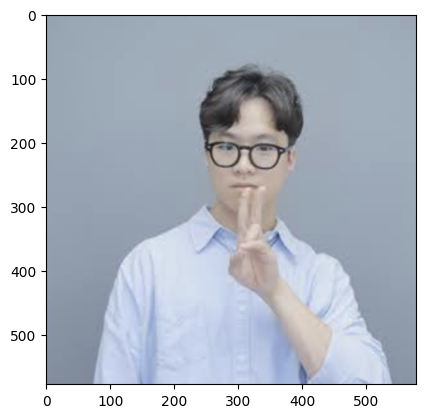

In [27]:
image = DATA_PATH / "data_external/user_000_test.png"
pred, conf = recog_system.recognize_face(image)
plt.imshow(Image.open(image))
print(f"pred: {pred}, conf: {conf:.3f}")

pred: user000, conf: 1.000


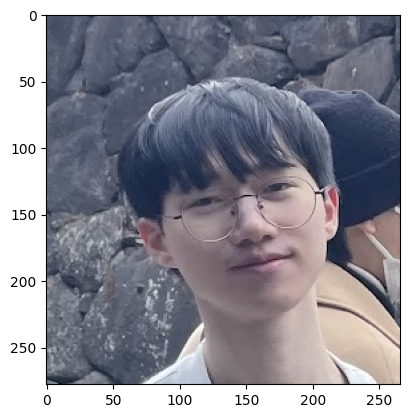

In [28]:
image = DATA_PATH / "data_external/user_001_1.png"
pred, conf = recog_system.recognize_face(image)
plt.imshow(Image.open(image))
print(f"pred: {pred}, conf: {conf:.3f}")